In [ ]:
import torch
import numpy as np
!pip install astra_toolbox
import astra
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 84.3 MB/s eta 0:00:00


In [ ]:
device = 'cuda' if torch.cuda.is_available() else ['line', 'line_fanflat']
FBP_type = 'FBP_CUDA' if device=='cuda' else 'FBP'

In [ ]:
def random_ellipses(num_of_ellipses: int,
                    size: tuple) -> torch.Tensor:

    # Pre-allocate PyTorch tensor for the ellipses
    ellipses = torch.zeros(size=((num_of_ellipses, ) + (size[0], size[1])))

    # Create linear spaces for the ellipses to be put into.
    # Note that x is a row vector and y is a column vector.
    x = torch.linspace(start=-size[0], end=size[1], steps=size[1])
    y = torch.linspace(start=-size[0], end=size[1], steps=size[0])[:,None]

    # Loop over the amount of ellipses needed.
    for k in range(num_of_ellipses):
        # Find a random points for center coordinates, height and width.
        x0 = np.random.randint(low=-size[0], high=size[0])
        y0 = np.random.randint(low=-size[1], high=size[1])
        a = np.random.randint(low=-size[0], high=size[0])
        b = np.random.randint(low=-size[1], high=size[1])

        # Use ellipse function to create them.
        ellipses[k,:,:] = ((x-x0)/a)**2 + ((y-y0)/b)**2 <= 1

        # Force the ellipse value to be random constant from uniform distribution
        # for each ellipse.
        ellipses[k,:,:][ellipses[k,:,:] == 1] = torch.rand(1)

    # Sum all ellipses together and normalize the data to be in [0,1].
    ellipses = torch.sum(ellipses, dim=0)
    ellipses /= torch.max(ellipses)

    return ellipses

def psnr(image1, image2):
    return 10*np.log10((np.max(image1))/(((image1-image2)**2).mean()+1e-10))

In [ ]:
# Define size and amount of ellipses
size = (256,256)
amount_of_ellipses = 50

# Call random_ellipses -function
ellipses = random_ellipses(amount_of_ellipses, size).numpy()

### Full angle projections

The full angle projections are such that rotate around the object.

That is, let $\theta_i \in \{ \frac{i-1}{N} 2\pi \}$, for all $i = 1, \ldots ,N$, where $N$ is the amount of increments within the interval.

Also let the amount of rays sent from the point source be $M \in \mathbb{Z}_+$.

In [ ]:
### Full angle forward operator and FBP

# Create a volume geometry of a size of variable "size".
vol_geom = astra.create_vol_geom(size)

# Define variables for the full angle Fan-Beam projection.
num_of_lines = 512
start_angle = 0
end_angle = np.pi
amount_of_angles = 720

angles = np.linspace(start_angle, end_angle, amount_of_angles)
SOD = 250
SDD = 260

# Create the Fan-Beam projction.
proj_geom = astra.create_proj_geom('parallel', 1.0, num_of_lines, angles)

# Create a sinogram using the CPU or GPU.
if device == 'cuda':
    proj_id_parall = astra.create_projector('cuda', proj_geom, vol_geom)
else:
    proj_id_parall = astra.create_projector(device[0], proj_geom, vol_geom)
parall_full_sinogram_id, parall_sinogram = astra.create_sino(ellipses, proj_id_parall)

astra.data2d.delete(proj_id_parall)

In [ ]:
### Full angle forward operator and FBP

# Create a volume geometry of a size of variable "size".
vol_geom = astra.create_vol_geom(size)

# Define variables for the full angle Fan-Beam projection.
num_of_lines = 512
start_angle = 0
end_angle = 2*np.pi
amount_of_angles = 720
angles = np.linspace(start_angle, end_angle, amount_of_angles)
SOD = 250
SDD = 260

# Create the Fan-Beam projction.
proj_geom = astra.create_proj_geom('fanflat', 1.0, num_of_lines, angles, SOD, SDD-SOD)

# Create a sinogram using the CPU or GPU.
if device == 'cuda':
    proj_id_full = astra.create_projector('cuda', proj_geom, vol_geom)
else:
    proj_id_full = astra.create_projector(device[1], proj_geom, vol_geom)
full_sinogram_id, full_sinogram = astra.create_sino(ellipses, proj_id_full)

astra.data2d.delete(proj_id_full)

### Sparse angle projections

The difference between full angle and sparse angle projections is that in sparse angle the amount of increments $N_{sparse} << N$.

In [ ]:
# Define variables for the sparse angle Fan-Beam projection.
num_of_lines = 512
start_angle = 0
end_angle = 2*np.pi
amount_of_angles = 30
angles = np.linspace(start_angle, end_angle, amount_of_angles)
SOD = 250
SDD = 260

# Create the Fan-Beam projction.
proj_geom = astra.create_proj_geom('fanflat', 1.0, num_of_lines, angles, SOD, SDD-SOD)

# Create a sinogram using the CPU or GPU.
if device == 'cuda':
    proj_id_sparse = astra.create_projector('cuda', proj_geom, vol_geom)
else:
    proj_id_sparse = astra.create_projector(device[1], proj_geom, vol_geom)
sparse_sinogram_id, sparse_sinogram = astra.create_sino(ellipses, proj_id_sparse)

astra.data2d.delete(proj_id_sparse)

### Limited angle projections

Finally the difference between full angle and limited angle projections is that in the limited angle projection the angle interval is cut short.

That is, for example let $\theta_i \in \{ \frac{i-1}{N_{limited}} \frac{\pi}{2} \}$. Here $N_{limited}$ does not need to be similar as in sparse.

In [ ]:
# Define variables for the limited angle Fan-Beam projection.
num_of_lines = 512
start_angle = 0
end_angle = np.pi/2
amount_of_angles = 360
angles = np.linspace(start_angle, end_angle, amount_of_angles)
SOD = 250
SDD = 260

# Create the Fan-Beam projction.
proj_geom = astra.create_proj_geom('fanflat', 1.0, num_of_lines, angles, SOD, SDD-SOD)

# Create a sinogram using the CPU or GPU.
if device == 'cuda':
    proj_id_limited = astra.create_projector('cuda', proj_geom, vol_geom)
else:
    proj_id_limited = astra.create_projector(device[1], proj_geom, vol_geom)
limited_sinogram_id, limited_sinogram = astra.create_sino(ellipses, proj_id_limited)

astra.data2d.delete(proj_id_limited)

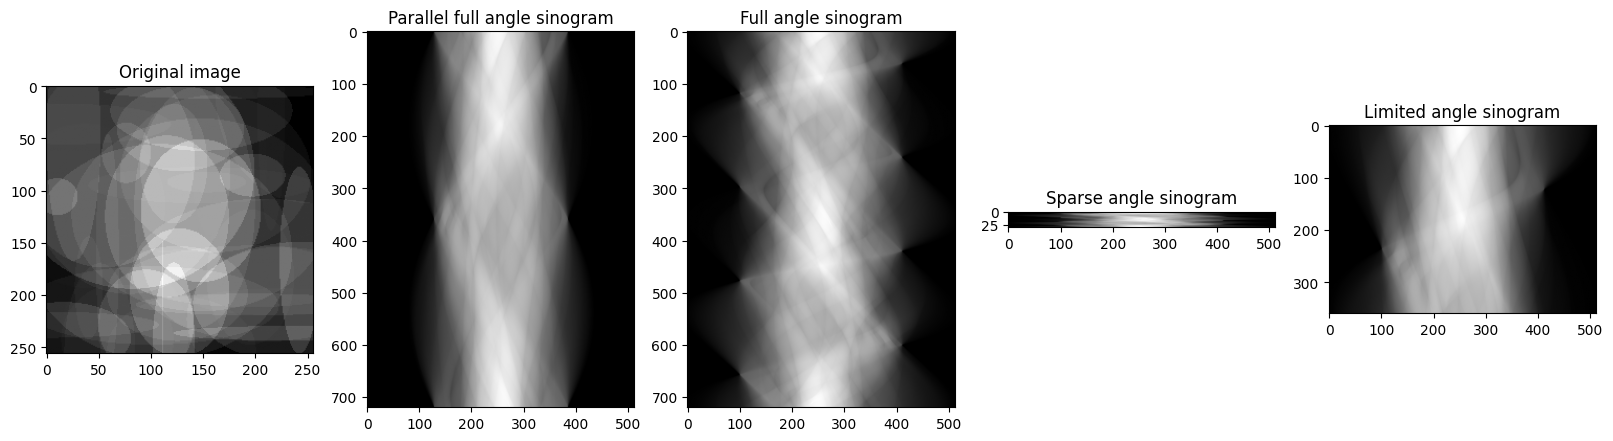

In [ ]:
_, ax = plt.subplots(1,5, figsize=(20,10))
ax[0].imshow(ellipses, cmap='gray')
ax[0].set_title('Original image')
ax[1].imshow(parall_sinogram, cmap='gray')
ax[1].set_title('Parallel full angle sinogram')
ax[2].imshow(full_sinogram, cmap='gray')
ax[2].set_title('Full angle sinogram')
ax[3].imshow(sparse_sinogram, cmap='gray')
ax[3].set_title('Sparse angle sinogram')
ax[4].imshow(limited_sinogram, cmap='gray')
ax[4].set_title('Limited angle sinogram')
plt.show()

PSNR of the adjoint case:  7.0633307 dB


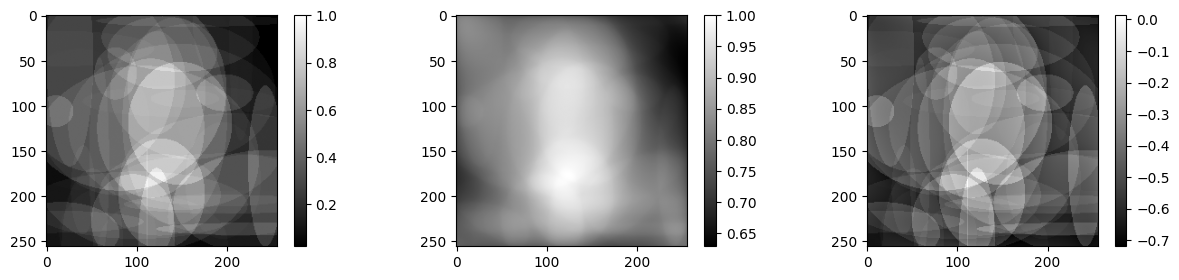

In [ ]:
# Define reconstruction id.
rec_id = astra.data2d.create('-vol', vol_geom)

# Create Filtered Back-Projection operator.
FBP = astra.astra_dict(FBP_type)

# Create FBP reconstruction.
cfg = FBP
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId'] = full_sinogram_id
cfg['option'] = { 'FilterType': 'None' }

alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id)

rec = astra.data2d.get(rec_id)
rec = np.maximum(0, rec)/(np.max(rec))

_, ax = plt.subplots(1,3, figsize=(15,3))
ax0 = ax[0].imshow(ellipses, cmap='gray')
_.colorbar(ax0, ax=ax[0])
ax1 = ax[1].imshow(rec, cmap='gray')
_.colorbar(ax1, ax=ax[1])
ax2 = ax[2].imshow((ellipses - rec), cmap='gray')
_.colorbar(ax2, ax=ax[2])

print('PSNR of the adjoint case: ', psnr(ellipses, rec), 'dB')

# Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
astra.algorithm.delete(alg_id)
astra.data2d.delete(rec_id)

PSNR of the full angle case:  39.972042 dB


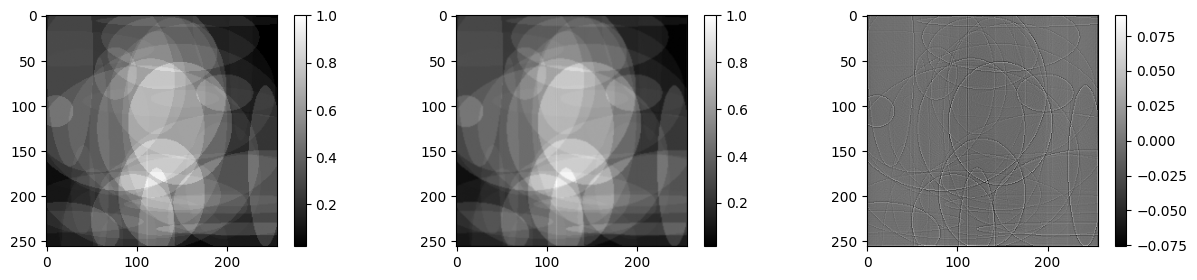

In [ ]:
# Define reconstruction id.
rec_id = astra.data2d.create('-vol', vol_geom)

# Create Filtered Back-Projection operator.
FBP = astra.astra_dict(FBP_type)

# Create FBP reconstruction.
cfg = FBP
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId'] = parall_full_sinogram_id
cfg['option'] = { 'FilterType': 'Ram-Lak' }

alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id)

rec_parall = astra.data2d.get(rec_id)
rec_parall = np.maximum(0, rec_parall)/(np.max(rec_parall))

_, ax = plt.subplots(1,3, figsize=(15,3))
ax0 = ax[0].imshow(ellipses, cmap='gray')
_.colorbar(ax0, ax=ax[0])
ax1 = ax[1].imshow(rec_parall, cmap='gray')
_.colorbar(ax1, ax=ax[1])
ax2 = ax[2].imshow((ellipses - rec_parall), cmap='gray')
_.colorbar(ax2, ax=ax[2])

print('PSNR of the full angle case: ', psnr(ellipses, rec_parall), 'dB')

# Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
astra.data2d.delete(parall_full_sinogram_id)
astra.algorithm.delete(alg_id)
astra.data2d.delete(rec_id)

PSNR of the full angle case:  37.000862 dB


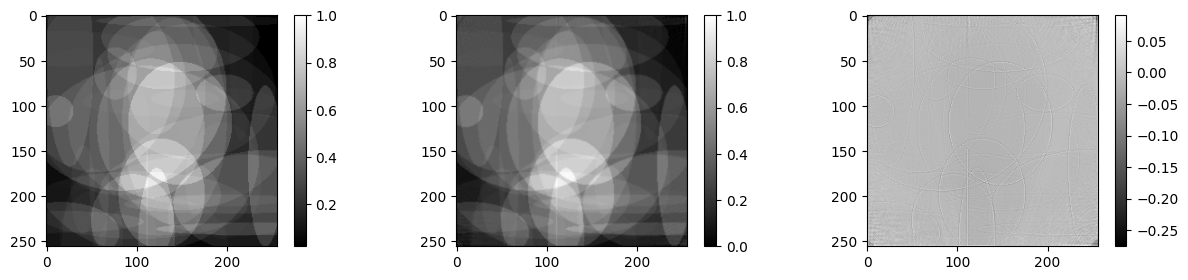

In [ ]:
# Define reconstruction id.
rec_id = astra.data2d.create('-vol', vol_geom)

# Create Filtered Back-Projection operator.
FBP = astra.astra_dict(FBP_type)

# Create FBP reconstruction.
cfg = FBP
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId'] = full_sinogram_id
cfg['option'] = { 'FilterType': 'Ram-Lak' }

alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id)

rec_full = astra.data2d.get(rec_id)
rec_full = np.maximum(0, rec_full)/(np.max(rec_full))

_, ax = plt.subplots(1,3, figsize=(15,3))
ax0 = ax[0].imshow(ellipses, cmap='gray')
_.colorbar(ax0, ax=ax[0])
ax1 = ax[1].imshow(rec_full, cmap='gray')
_.colorbar(ax1, ax=ax[1])
ax2 = ax[2].imshow((ellipses - rec_full), cmap='gray')
_.colorbar(ax2, ax=ax[2])

print('PSNR of the full angle case: ', psnr(ellipses, rec_full), 'dB')

# Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
astra.data2d.delete(full_sinogram_id)
astra.algorithm.delete(alg_id)
astra.data2d.delete(rec_id)

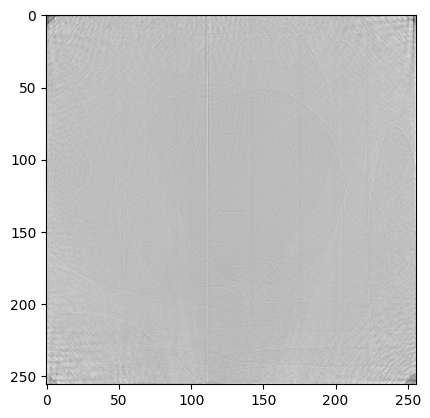

In [ ]:
plt.figure()
plt.imshow(rec_parall-rec_full, cmap='gray')
plt.show()

PSNR of the sparse angle case:  19.98777 dB


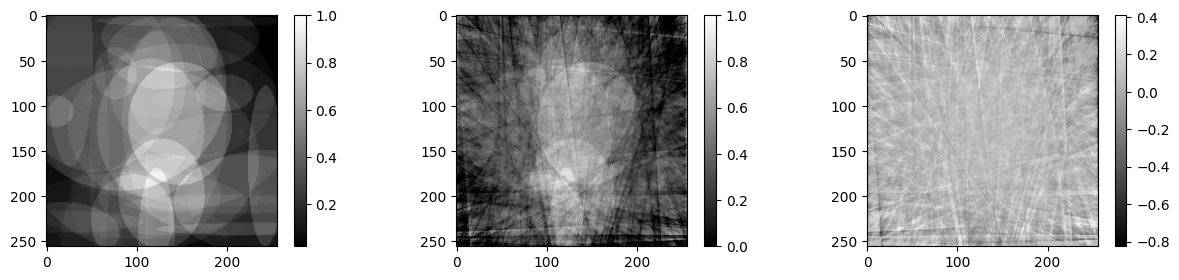

In [ ]:
# Define reconstruction id.
rec_id = astra.data2d.create('-vol', vol_geom)

# Create Filtered Back-Projection operator.
FBP = astra.astra_dict(FBP_type)

# Create FBP reconstruction.
cfg = FBP
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId'] = sparse_sinogram_id
cfg['option'] = { 'FilterType': 'Ram-Lak' }

alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id)

rec_sparse = astra.data2d.get(rec_id)
rec_sparse = np.maximum(0, rec_sparse)/np.max(rec_sparse)

_, ax = plt.subplots(1,3, figsize=(15,3))
ax0 = ax[0].imshow(ellipses, cmap='gray')
_.colorbar(ax0, ax=ax[0])
ax1 = ax[1].imshow(rec_sparse, cmap='gray')
_.colorbar(ax1, ax=ax[1])
ax2 = ax[2].imshow((ellipses - rec_sparse), cmap='gray')
_.colorbar(ax2, ax=ax[2])

print('PSNR of the sparse angle case: ', psnr(ellipses, rec_sparse), 'dB')

# Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
astra.data2d.delete(full_sinogram_id)
astra.algorithm.delete(alg_id)
astra.data2d.delete(rec_id)

PSNR of the limited angle case:  12.658706 dB


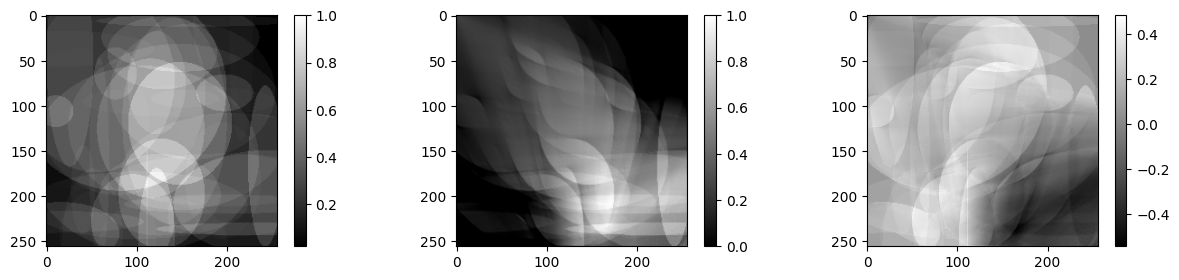

In [ ]:
# Define reconstruction id.
rec_id = astra.data2d.create('-vol', vol_geom)

# Create Filtered Back-Projection operator.
FBP = astra.astra_dict(FBP_type)

# Create FBP reconstruction.
cfg = FBP
cfg['ReconstructionDataId'] = rec_id
cfg['ProjectionDataId'] = limited_sinogram_id
cfg['option'] = { 'FilterType': 'Ram-Lak' }

alg_id = astra.algorithm.create(cfg)
astra.algorithm.run(alg_id)

rec_limited = astra.data2d.get(rec_id)
rec_limited = np.maximum(0, rec_limited)/np.max(rec_limited)

_, ax = plt.subplots(1,3, figsize=(15,3))
ax0 = ax[0].imshow(ellipses, cmap='gray')
_.colorbar(ax0, ax=ax[0])
ax1 = ax[1].imshow(rec_limited, cmap='gray')
_.colorbar(ax1, ax=ax[1])
ax2 = ax[2].imshow((ellipses - rec_limited), cmap='gray')
_.colorbar(ax2, ax=ax[2])

print('PSNR of the limited angle case: ', psnr(ellipses, rec_limited), 'dB')

# Free memory, THIS IS EXTREMELY NECESSARY WITH ASTRA!
astra.data2d.delete(full_sinogram_id)
astra.algorithm.delete(alg_id)
astra.data2d.delete(rec_id)

In [ ]:
### TASK: Create sparse and limited angle projections and backprojections
### for Parallel beam case.
### Also compare 180° parallel beam to 180° fan beam with same amonut of angles.